In [10]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import table
from PIL import Image

from xbbg import blp
from datetime import datetime, timedelta
from typing import List, Optional, Tuple, Dict
from itertools import permutations

from itertools import product
from scipy.stats import percentileofscore, gaussian_kde, norm
from scipy.stats import zscore
import math
from itertools import combinations




def ATM_VolRefferenceRanking_AllTenorCCY_FullTimePannel(currency_list, tenors):
    def xCCY_AllPairs_MultiTenor_Analysis(currency_list: List[str], tenor_list: List[str]):
        end_date = datetime.now().strftime("%Y-%m-%d")
        start_date = (datetime.now() - timedelta(days=365*6)).strftime("%Y-%m-%d")
        base_ccy = sorted(set(currency_list))  # These are currency pairs like EURUSD, GBPUSD, etc.
        results_by_tenor: Dict[str, pd.DataFrame] = {}
        currency_avg_metrics: Dict[str, pd.DataFrame] = {}
        correlation_data: Dict[str, pd.DataFrame] = {}  # Store correlation data for each tenor
        for tenor in tenor_list:
            data_dict: Dict[str, pd.Series] = {}
            for ccy_pair in base_ccy:  # ccy_pair is like 'EURUSD'
                ticker_IV = f"{ccy_pair}V{tenor} BGN Curncy"
                try:
                    data_IV = blp.bdh(
                        tickers=ticker_IV,
                        flds="PX_LAST",
                        start_date=start_date,
                        end_date=end_date)
                    data_IV.columns = data_IV.columns.get_level_values(1)
                    data_dict[ccy_pair] = data_IV['PX_LAST']
                except Exception as e:
                    continue
            if not data_dict:
                continue
            df_all = pd.DataFrame(data_dict).dropna()
            if df_all.empty:
                continue
            correlation_matrix = df_all.corr()
            correlation_data[tenor] = correlation_matrix
            latest_date = df_all.index[-1]
            currency_pairs = list(permutations(base_ccy, 2))  # All combinations of currency pairs
            pair_results = []
            currency_volatilities: Dict[str, List[Dict[str, float]]] = {ccy_pair: [] for ccy_pair in base_ccy}
            for ccy_pair1, ccy_pair2 in currency_pairs:  # e.g., ('EURUSD', 'USDJPY')
                if ccy_pair1 not in df_all.columns or ccy_pair2 not in df_all.columns:
                    continue
                current_spread = df_all.loc[latest_date, ccy_pair1] - df_all.loc[latest_date, ccy_pair2]
                historical_spreads = df_all[ccy_pair1] - df_all[ccy_pair2]
                three_months_ago = latest_date - timedelta(days=90)
                one_year_ago    = latest_date - timedelta(days=365)
                three_years_ago = latest_date - timedelta(days=365*3)
                five_years_ago  = latest_date - timedelta(days=365*5)
                past_3_months_spreads = historical_spreads.loc[historical_spreads.index >= three_months_ago]
                past_year_spreads     = historical_spreads.loc[historical_spreads.index >= one_year_ago]
                past_3_years_spreads  = historical_spreads.loc[historical_spreads.index >= three_years_ago]
                past_5_years_spreads  = historical_spreads.loc[historical_spreads.index >= five_years_ago]
                if len(past_5_years_spreads) < 2:
                    continue
                percentile_3_months = percentileofscore(past_3_months_spreads, current_spread)
                percentile_1_year   = percentileofscore(past_year_spreads,     current_spread)
                percentile_3_years  = percentileofscore(past_3_years_spreads,  current_spread) if len(past_3_years_spreads) > 1 else None
                percentile_5_years  = percentileofscore(past_5_years_spreads,  current_spread) if len(past_5_years_spreads) > 1 else None
                spread_volatility_3m = past_3_months_spreads.std()
                spread_volatility_1y = past_year_spreads.std()
                spread_volatility_3y = past_3_years_spreads.std() if len(past_3_years_spreads) > 1 else None
                spread_volatility_5y = past_5_years_spreads.std() if len(past_5_years_spreads) > 1 else None
                mean_spread_3m = past_3_months_spreads.mean()
                mean_spread_1y = past_year_spreads.mean()
                mean_spread_3y = past_3_years_spreads.mean() if len(past_3_years_spreads) > 1 else None
                mean_spread_5y = past_5_years_spreads.mean() if len(past_5_years_spreads) > 1 else None
                relative_position_3m = (current_spread - mean_spread_3m) / spread_volatility_3m if spread_volatility_3m and spread_volatility_3m > 0 else 0
                relative_position_1y = (current_spread - mean_spread_1y) / spread_volatility_1y if spread_volatility_1y and spread_volatility_1y > 0 else 0
                relative_position_3y = ((current_spread - mean_spread_3y) / spread_volatility_3y
                                        if (spread_volatility_3y and spread_volatility_3y > 0 and mean_spread_3y is not None) else None)
                relative_position_5y = ((current_spread - mean_spread_5y)/ spread_volatility_5y
                                        if (spread_volatility_5y and spread_volatility_5y > 0 and mean_spread_5y is not None) else None)
                correlation = correlation_matrix.loc[ccy_pair1, ccy_pair2] if (ccy_pair1 in correlation_matrix.index and ccy_pair2 in correlation_matrix.columns) else None
                pair_result = {
                    'Tenor': tenor,
                    'Pair': f"{ccy_pair1}-{ccy_pair2}",
                    'CCY1': ccy_pair1,  # Now this is a currency pair like 'EURUSD'
                    'CCY2': ccy_pair2,  # Now this is a currency pair like 'USDJPY'
                    'Correlation': round(correlation, 4) if correlation is not None else None,
                    'Current_Spread': round(current_spread, 4),

                    'Spread_Mean_3M': round(mean_spread_3m, 4) if mean_spread_3m is not None else None,
                    'Spread_Mean_1Y': round(mean_spread_1y, 4) if mean_spread_3m is not None else None,
                    'Spread_Mean_3Y': round(mean_spread_3y, 4) if mean_spread_3m is not None else None,
                    'Spread_Mean_5Y': round(mean_spread_5y, 4) if mean_spread_3m is not None else None,


                    'Spread_STD_3M': round(spread_volatility_3m, 4) if spread_volatility_3m is not None else None,
                    'Spread_STD_1Y': round(spread_volatility_1y, 4) if spread_volatility_1y is not None else None,
                    'Spread_STD_3Y': round(spread_volatility_3y, 4) if spread_volatility_3y is not None else None,
                    'Spread_STD_5Y': round(spread_volatility_5y, 4) if spread_volatility_5y is not None else None,
                    'Spread_ZScore_3M': round(relative_position_3m, 4) if relative_position_3m is not None else None,
                    'Spread_ZScore_1Y': round(relative_position_1y, 4) if relative_position_1y is not None else None,
                    'Spread_ZScore_3Y': round(relative_position_3y, 4) if relative_position_3y is not None else None,
                    'Spread_ZScore_5Y': round(relative_position_5y, 4) if relative_position_5y is not None else None,
                    'Percentile_3M': round(percentile_3_months, 3) if percentile_3_months is not None else None,
                    'Percentile_1Y': round(percentile_1_year, 3) if percentile_1_year is not None else None,
                    'Percentile_3Y': round(percentile_3_years, 3) if percentile_3_years is not None else None,
                    'Percentile_5Y': round(percentile_5_years, 3) if percentile_5_years is not None else None}
                pair_results.append(pair_result)
                if spread_volatility_1y is not None and relative_position_1y is not None:
                    currency_volatilities[ccy_pair1].append({
                        'Spread_STD_1y': spread_volatility_1y,
                        'Spread_ZScore_1y': relative_position_1y,
                        'pair': f"{ccy_pair1}-{ccy_pair2}"})
            results_by_tenor[tenor] = pd.DataFrame(pair_results)
            tenor_currency_averages = []
            for ccy_pair in base_ccy:
                if currency_volatilities[ccy_pair]:
                    avg_spread_vol = np.mean([x['Spread_STD_1y'] for x in currency_volatilities[ccy_pair]])
                    avg_relative_pos = np.mean([x['Spread_ZScore_1y'] for x in currency_volatilities[ccy_pair]])
                    num_pairs = len(currency_volatilities[ccy_pair])
                    tenor_currency_averages.append({
                        'Currency': ccy_pair,  # Now this is a currency pair like 'EURUSD'
                        'Tenor': tenor,
                        'Avg_Spread_STD_1Y': round(avg_spread_vol, 4),
                        'Avg_Spread_ZScore_1Y': round(avg_relative_pos, 4),
                        'Num_Pairs': num_pairs})
            currency_avg_metrics[tenor] = pd.DataFrame(tenor_currency_averages).sort_values('Avg_Spread_STD_1Y')
        return results_by_tenor, currency_avg_metrics, correlation_data
    # ----------------------------- Averaging Spreads -----------------------------
    # ------ Finding Averages of Each Pair Spread (Pair - CCY_Other) for Each Tenor ------
    def find_ave_allCCYallLookback_equalWeights(results_by_tenor, tenors):
        tenor_results = {}  
        for tenor in tenors:
            if tenor in results_by_tenor:
                df = results_by_tenor[tenor]
                all_currency_pairs = set(df['CCY1'].tolist() + df['CCY2'].tolist())
                currency_percentile_summary = []
                for ccy_pair in all_currency_pairs:  # ccy_pair is like 'EURUSD'
                    ccy_pairs = df[df['CCY1'] == ccy_pair]  # All pairs where EURUSD is first
                    if len(ccy_pairs) > 0:
                        avg_percentile_3m = ccy_pairs['Percentile_3M'].mean()
                        avg_percentile_1y = ccy_pairs['Percentile_1Y'].mean()
                        percentile_3y_values = ccy_pairs['Percentile_3Y'].dropna()
                        percentile_5y_values = ccy_pairs['Percentile_5Y'].dropna()
                        avg_percentile_3y = percentile_3y_values.mean() if len(percentile_3y_values) > 0 else None
                        avg_percentile_5y = percentile_5y_values.mean() if len(percentile_5y_values) > 0 else None
                        currency_percentile_summary.append({
                            'Currency_Pair': ccy_pair,  # Updated column name for clarity
                            'Tenor': tenor,
                            'Avg_EquWeight_3M%': round(avg_percentile_3m, 3),
                            'Avg_EquWeight_1Y%': round(avg_percentile_1y, 3),
                            'Avg_EquWeight_3Y%': round(avg_percentile_3y, 3) if avg_percentile_3y is not None else None,
                            'Avg_EquWeight_5Y%': round(avg_percentile_5y, 3) if avg_percentile_5y is not None else None,
                            'Num_Pairs': len(ccy_pairs)})
                percentile_df = pd.DataFrame(currency_percentile_summary).sort_values('Avg_EquWeight_5Y%')
                tenor_results[tenor] = percentile_df
        return tenor_results
    # ------  Correlation-Weighted Averaging Function ------
    def find_ave_allCCYallLookback_correlationWeights(results_by_tenor, tenors):
        tenor_results = {}  
        for tenor in tenors:
            if tenor in results_by_tenor:
                df = results_by_tenor[tenor]
                all_currency_pairs = set(df['CCY1'].tolist() + df['CCY2'].tolist())
                currency_percentile_summary = []
                for ccy_pair in all_currency_pairs:  # ccy_pair is like 'EURUSD'
                    ccy_pairs = df[df['CCY1'] == ccy_pair].copy()  # All pairs where EURUSD is first
                    if len(ccy_pairs) > 0:
                        ccy_pairs_valid = ccy_pairs.dropna(subset=['Correlation'])
                        if len(ccy_pairs_valid) == 0:
                            weights = np.ones(len(ccy_pairs)) / len(ccy_pairs)
                            ccy_pairs_for_calc = ccy_pairs
                        else:
                            correlation_weights = ccy_pairs_valid['Correlation'].abs()  # Use absolute correlation
                            weights = correlation_weights / correlation_weights.sum()  # Normalize to sum to 1
                            ccy_pairs_for_calc = ccy_pairs_valid
                        weighted_avg_percentile_3m = np.average(ccy_pairs_for_calc['Percentile_3M'], weights=weights)
                        weighted_avg_percentile_1y = np.average(ccy_pairs_for_calc['Percentile_1Y'], weights=weights)
                        percentile_3y_valid = ccy_pairs_for_calc['Percentile_3Y'].dropna()
                        percentile_5y_valid = ccy_pairs_for_calc['Percentile_5Y'].dropna()
                        weighted_avg_percentile_3y = None
                        weighted_avg_percentile_5y = None
                        if len(percentile_3y_valid) > 0:
                            valid_3y_indices = ccy_pairs_for_calc['Percentile_3Y'].dropna().index
                            weights_3y = weights[ccy_pairs_for_calc.index.isin(valid_3y_indices)]
                            weights_3y = weights_3y / weights_3y.sum()  # Renormalize
                            weighted_avg_percentile_3y = np.average(percentile_3y_valid, weights=weights_3y)
                        if len(percentile_5y_valid) > 0:
                            # Get weights for valid 5Y data
                            valid_5y_indices = ccy_pairs_for_calc['Percentile_5Y'].dropna().index
                            weights_5y = weights[ccy_pairs_for_calc.index.isin(valid_5y_indices)]
                            weights_5y = weights_5y / weights_5y.sum()  # Renormalize
                            weighted_avg_percentile_5y = np.average(percentile_5y_valid, weights=weights_5y)
                        avg_correlation = ccy_pairs_valid['Correlation'].mean() if len(ccy_pairs_valid) > 0 else None
                        currency_percentile_summary.append({
                            'Currency_Pair': ccy_pair,  # Updated column name for clarity
                            'Tenor': tenor,
                            'Avg_CorrWeight_3M%': round(weighted_avg_percentile_3m, 3),
                            'Avg_CorrWeight_1Y%': round(weighted_avg_percentile_1y, 3),
                            'Avg_CorrWeight_3Y%': round(weighted_avg_percentile_3y, 3) if weighted_avg_percentile_3y is not None else None,
                            'Avg_CorrWeight_5Y%': round(weighted_avg_percentile_5y, 3) if weighted_avg_percentile_5y is not None else None,
                            'Num_Pairs': len(ccy_pairs)})
                percentile_df = pd.DataFrame(currency_percentile_summary).sort_values('Avg_CorrWeight_5Y%', ascending=False)
                tenor_results[tenor] = percentile_df
        return tenor_results
    # --------------------- Executing Functions ---------------------
    results_by_tenor, currency_avg_metrics, correlation_data = xCCY_AllPairs_MultiTenor_Analysis(
        currency_list, tenors)
    ave_tenorBuckets_equalBuckets = find_ave_allCCYallLookback_equalWeights(results_by_tenor, tenors)
    ave_tenorBuckets_correlationWeighted = find_ave_allCCYallLookback_correlationWeights(results_by_tenor, tenors)
    return {
        'results_by_tenor': results_by_tenor,
        'ave_results_by_tenor_equalWeights': ave_tenorBuckets_equalBuckets,
        'ave_results_by_tenor_correlationWeighted': ave_tenorBuckets_correlationWeighted,
        'correlation_data': correlation_data}








def get_cleanIndividual_pairSpread_Tenors(analysis_results, tenor):
    data_single = analysis_results["results_by_tenor"][tenor].copy()
    df = data_single.copy()
    df_clean = df[['Tenor', 'Pair', 'CCY1', 'CCY2', 'Current_Spread', 'Percentile_3M', 'Percentile_1Y', 'Percentile_3Y', 'Percentile_5Y']]
    df_clean = df_clean.sort_values('Percentile_1Y', ascending=False)
    seen_pairs = set()
    rows_to_keep = []
    for idx, row in df_clean.iterrows():
        ccy1 = row['CCY1']
        ccy2 = row['CCY2']
        pair_key = tuple(sorted([ccy1, ccy2]))
        
        if pair_key not in seen_pairs:
            rows_to_keep.append(idx)
            seen_pairs.add(pair_key)
    df_clean = df_clean.loc[rows_to_keep]

    df_present = df_clean[['Tenor', 'Pair', 'Current_Spread', 'Percentile_3M', 'Percentile_1Y', 'Percentile_3Y', 'Percentile_5Y']]
    return df_present







currency_list_broad = ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 
                       'USDCAD', 'USDCHF', 'USDCNH']
tenor_interest = ['1M']

analysis_results = ATM_VolRefferenceRanking_AllTenorCCY_FullTimePannel(currency_list_broad, tenor_interest)

data_single = get_cleanIndividual_pairSpread_Tenors(analysis_results, tenor_interest[0])


pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)
data_single


,Tenor,Pair,Current_Spread,Percentile_3M,Percentile_1Y,Percentile_3Y,Percentile_5Y
2,1M,AUDUSD-NZDUSD,0.1200,96.923,92.748,90.944,87.768
15,1M,GBPUSD-EURUSD,0.3350,100.000,88.931,39.222,30.330
17,1M,GBPUSD-USDCAD,2.5025,87.692,87.023,80.102,77.531
0,1M,AUDUSD-EURUSD,2.3625,96.923,86.260,31.760,26.610
3,1M,AUDUSD-USDCAD,4.5300,93.846,81.679,69.260,75.537
36,1M,USDCHF-EURUSD,0.7325,100.000,81.298,73.852,78.758
5,1M,AUDUSD-USDCNH,5.8350,83.846,77.672,82.844,75.805
22,1M,NZDUSD-EURUSD,2.2425,98.462,76.718,27.423,23.083
24,1M,NZDUSD-USDCAD,4.4100,93.846,75.573,62.117,70.782
39,1M,USDCHF-USDCAD,2.9000,66.154,69.847,85.332,91.181


In [5]:
def get_cleanIndividual_pairSpread_Tenors_ZScore(analysis_results, tenor):
    data_single = analysis_results["results_by_tenor"][tenor].copy()
    df = data_single.copy()
    
    # Select z-score columns instead of percentile columns
    df_clean = df[['Tenor', 'Pair', 'CCY1', 'CCY2', 'Current_Spread', 
                   'Spread_ZScore_3M', 'Spread_ZScore_1Y', 'Spread_ZScore_3Y', 'Spread_ZScore_5Y']]
    
    # Sort by 1Y z-score in descending order
    df_clean = df_clean.sort_values('Spread_ZScore_1Y', ascending=False)
    
    # Remove duplicate pairs (keep only one direction)
    seen_pairs = set()
    rows_to_keep = []
    for idx, row in df_clean.iterrows():
        ccy1 = row['CCY1']
        ccy2 = row['CCY2']
        pair_key = tuple(sorted([ccy1, ccy2]))
        
        if pair_key not in seen_pairs:
            rows_to_keep.append(idx)
            seen_pairs.add(pair_key)
    
    df_clean = df_clean.loc[rows_to_keep]
    
    df_present = df_clean[['Tenor', 'Pair', 'Current_Spread', 
                           'Spread_ZScore_3M', 'Spread_ZScore_1Y', 
                           'Spread_ZScore_3Y', 'Spread_ZScore_5Y']]
    
    return df_present

In [6]:
data_single_zscore = get_cleanIndividual_pairSpread_Tenors_ZScore(analysis_results, tenor_interest[0])
data_single_zscore

,Tenor,Pair,Current_Spread,Spread_ZScore_3M,Spread_ZScore_1Y,Spread_ZScore_3Y,Spread_ZScore_5Y
15,1W,GBPUSD-EURUSD,0.5650,2.4622,1.2770,0.1152,-0.1706
36,1W,USDCHF-EURUSD,1.0500,2.7557,0.9811,0.6636,0.7946
0,1W,AUDUSD-EURUSD,2.5225,2.6654,0.9504,-0.0504,-0.1555
22,1W,NZDUSD-EURUSD,2.6800,1.7788,0.8846,-0.0884,-0.1918
50,1W,USDJPY-EURUSD,3.1750,1.6874,0.7503,0.0580,0.4969
17,1W,GBPUSD-USDCAD,2.5225,0.7265,0.6728,0.4812,0.4043
3,1W,AUDUSD-USDCAD,4.4800,1.9915,0.5449,0.2689,0.5491
24,1W,NZDUSD-USDCAD,4.6375,1.3997,0.5270,0.2186,0.4964
43,1W,USDCNH-EURUSD,-3.2350,1.4220,0.4283,-0.4176,-0.4183
39,1W,USDCHF-USDCAD,3.0075,0.5260,0.4245,0.7965,1.1892


In [11]:
def ATM_VolRefferenceRanking_AllTenorCCY_FullTimePannel(currency_list, tenors, lookback_days=252):
    def xCCY_AllPairs_MultiTenor_Analysis(currency_list: List[str], tenor_list: List[str]):
        end_date = datetime.now().strftime("%Y-%m-%d")
        start_date = (datetime.now() - timedelta(days=365*6)).strftime("%Y-%m-%d")
        base_ccy = sorted(set(currency_list))  # These are currency pairs like EURUSD, GBPUSD, etc.
        results_by_tenor: Dict[str, pd.DataFrame] = {}
        currency_avg_metrics: Dict[str, pd.DataFrame] = {}
        correlation_data: Dict[str, pd.DataFrame] = {}  # Store correlation data for each tenor
        df_all_by_tenor: Dict[str, pd.DataFrame] = {}  # Store df_all for each tenor for beta calculations
        for tenor in tenor_list:
            data_dict: Dict[str, pd.Series] = {}
            for ccy_pair in base_ccy:  # ccy_pair is like 'EURUSD'
                ticker_IV = f"{ccy_pair}V{tenor} BGN Curncy"
                try:
                    data_IV = blp.bdh(
                        tickers=ticker_IV,
                        flds="PX_LAST",
                        start_date=start_date,
                        end_date=end_date)
                    data_IV.columns = data_IV.columns.get_level_values(1)
                    data_dict[ccy_pair] = data_IV['PX_LAST']
                except Exception as e:
                    continue
            if not data_dict:
                continue
            df_all = pd.DataFrame(data_dict).dropna()
            if df_all.empty:
                continue
            df_all_by_tenor[tenor] = df_all
            # correlation_matrix = df_all.corr()
            correlation_matrix = df_all.diff().dropna().corr()
            correlation_data[tenor] = correlation_matrix
            latest_date = df_all.index[-1]
            currency_pairs = list(permutations(base_ccy, 2))  # All combinations of currency pairs
            pair_results = []
            currency_volatilities: Dict[str, List[Dict[str, float]]] = {ccy_pair: [] for ccy_pair in base_ccy}
            for ccy_pair1, ccy_pair2 in currency_pairs:  # e.g., ('EURUSD', 'USDJPY')
                if ccy_pair1 not in df_all.columns or ccy_pair2 not in df_all.columns:
                    continue
                current_spread = df_all.loc[latest_date, ccy_pair1] - df_all.loc[latest_date, ccy_pair2]
                historical_spreads = df_all[ccy_pair1] - df_all[ccy_pair2]
                three_months_ago = latest_date - timedelta(days=90)
                one_year_ago    = latest_date - timedelta(days=365)
                three_years_ago = latest_date - timedelta(days=365*3)
                five_years_ago  = latest_date - timedelta(days=365*5)
                past_3_months_spreads = historical_spreads.loc[historical_spreads.index >= three_months_ago]
                past_year_spreads     = historical_spreads.loc[historical_spreads.index >= one_year_ago]
                past_3_years_spreads  = historical_spreads.loc[historical_spreads.index >= three_years_ago]
                past_5_years_spreads  = historical_spreads.loc[historical_spreads.index >= five_years_ago]
                if len(past_5_years_spreads) < 2:
                    continue
                percentile_3_months = percentileofscore(past_3_months_spreads, current_spread)
                percentile_1_year   = percentileofscore(past_year_spreads,     current_spread)
                percentile_3_years  = percentileofscore(past_3_years_spreads,  current_spread) if len(past_3_years_spreads) > 1 else None
                percentile_5_years  = percentileofscore(past_5_years_spreads,  current_spread) if len(past_5_years_spreads) > 1 else None
                spread_volatility_3m = past_3_months_spreads.std()
                spread_volatility_1y = past_year_spreads.std()
                spread_volatility_3y = past_3_years_spreads.std() if len(past_3_years_spreads) > 1 else None
                spread_volatility_5y = past_5_years_spreads.std() if len(past_5_years_spreads) > 1 else None
                mean_spread_3m = past_3_months_spreads.mean()
                mean_spread_1y = past_year_spreads.mean()
                mean_spread_3y = past_3_years_spreads.mean() if len(past_3_years_spreads) > 1 else None
                mean_spread_5y = past_5_years_spreads.mean() if len(past_5_years_spreads) > 1 else None
                relative_position_3m = abs(current_spread - mean_spread_3m) / spread_volatility_3m if spread_volatility_3m and spread_volatility_3m > 0 else 0
                relative_position_1y = abs(current_spread - mean_spread_1y) / spread_volatility_1y if spread_volatility_1y and spread_volatility_1y > 0 else 0
                relative_position_3y = (abs(current_spread - mean_spread_3y) / spread_volatility_3y
                                        if (spread_volatility_3y and spread_volatility_3y > 0 and mean_spread_3y is not None) else None)
                relative_position_5y = (abs(current_spread - mean_spread_5y) / spread_volatility_5y
                                        if (spread_volatility_5y and spread_volatility_5y > 0 and mean_spread_5y is not None) else None)
                correlation = correlation_matrix.loc[ccy_pair1, ccy_pair2] if (ccy_pair1 in correlation_matrix.index and ccy_pair2 in correlation_matrix.columns) else None
                pair_result = {
                    'Tenor': tenor,
                    'Pair': f"{ccy_pair1}-{ccy_pair2}",
                    'CCY1': ccy_pair1,  # Now this is a currency pair like 'EURUSD'
                    'CCY2': ccy_pair2,  # Now this is a currency pair like 'USDJPY'
                    'Correlation': round(correlation, 4) if correlation is not None else None,
                    'Current_Spread': round(current_spread, 4),
                    'Spread_Mean_3M': round(mean_spread_3m, 4) if mean_spread_3m is not None else None,
                    'Spread_Mean_1Y': round(mean_spread_1y, 4) if mean_spread_1y is not None else None,
                    'Spread_Mean_3Y': round(mean_spread_3y, 4) if mean_spread_3y is not None else None,
                    'Spread_Mean_5Y': round(mean_spread_5y, 4) if mean_spread_5y is not None else None,
                    'Spread_STD_3M': round(spread_volatility_3m, 4) if spread_volatility_3m is not None else None,
                    'Spread_STD_1Y': round(spread_volatility_1y, 4) if spread_volatility_1y is not None else None,
                    'Spread_STD_3Y': round(spread_volatility_3y, 4) if spread_volatility_3y is not None else None,
                    'Spread_STD_5Y': round(spread_volatility_5y, 4) if spread_volatility_5y is not None else None,
                    'Spread_ZScore_3M': round(relative_position_3m, 4) if relative_position_3m is not None else None,
                    'Spread_ZScore_1Y': round(relative_position_1y, 4) if relative_position_1y is not None else None,
                    'Spread_ZScore_3Y': round(relative_position_3y, 4) if relative_position_3y is not None else None,
                    'Spread_ZScore_5Y': round(relative_position_5y, 4) if relative_position_5y is not None else None,
                    'Percentile_3M': round(percentile_3_months, 3) if percentile_3_months is not None else None,
                    'Percentile_1Y': round(percentile_1_year, 3) if percentile_1_year is not None else None,
                    'Percentile_3Y': round(percentile_3_years, 3) if percentile_3_years is not None else None,
                    'Percentile_5Y': round(percentile_5_years, 3) if percentile_5_years is not None else None}
                pair_results.append(pair_result)
                if spread_volatility_1y is not None and relative_position_1y is not None:
                    currency_volatilities[ccy_pair1].append({
                        'Spread_STD_1y': spread_volatility_1y,
                        'Spread_ZScore_1y': relative_position_1y,
                        'pair': f"{ccy_pair1}-{ccy_pair2}"})
            results_by_tenor[tenor] = pd.DataFrame(pair_results)
            tenor_currency_averages = []
            for ccy_pair in base_ccy:
                if currency_volatilities[ccy_pair]:
                    avg_spread_vol = np.mean([x['Spread_STD_1y'] for x in currency_volatilities[ccy_pair]])
                    avg_relative_pos = np.mean([x['Spread_ZScore_1y'] for x in currency_volatilities[ccy_pair]])
                    num_pairs = len(currency_volatilities[ccy_pair])
                    tenor_currency_averages.append({
                        'Currency': ccy_pair,  # Now this is a currency pair like 'EURUSD'
                        'Tenor': tenor,
                        'Avg_Spread_STD_1Y': round(avg_spread_vol, 4),
                        'Avg_Spread_ZScore_1Y': round(avg_relative_pos, 4),
                        'Num_Pairs': num_pairs})
            currency_avg_metrics[tenor] = pd.DataFrame(tenor_currency_averages).sort_values('Avg_Spread_STD_1Y')
        return results_by_tenor, currency_avg_metrics, correlation_data, df_all_by_tenor
    
    # ----------------------------- Averaging Spreads -----------------------------
    # ------ Finding Averages of Each Pair Spread (Pair - CCY_Other) for Each Tenor ------
    def find_ave_allCCYallLookback_equalWeights(results_by_tenor, tenors):
        tenor_results = {}  
        for tenor in tenors:
            if tenor in results_by_tenor:
                df = results_by_tenor[tenor]
                all_currency_pairs = set(df['CCY1'].tolist() + df['CCY2'].tolist())
                currency_percentile_summary = []
                for ccy_pair in all_currency_pairs:  # ccy_pair is like 'EURUSD'
                    ccy_pairs = df[df['CCY1'] == ccy_pair]  # All pairs where EURUSD is first
                    if len(ccy_pairs) > 0:
                        avg_percentile_3m = ccy_pairs['Percentile_3M'].mean()
                        avg_percentile_1y = ccy_pairs['Percentile_1Y'].mean()
                        percentile_3y_values = ccy_pairs['Percentile_3Y'].dropna()
                        percentile_5y_values = ccy_pairs['Percentile_5Y'].dropna()
                        avg_percentile_3y = percentile_3y_values.mean() if len(percentile_3y_values) > 0 else None
                        avg_percentile_5y = percentile_5y_values.mean() if len(percentile_5y_values) > 0 else None
                        currency_percentile_summary.append({
                            'Currency_Pair': ccy_pair,  # Updated column name for clarity
                            'Tenor': tenor,
                            'Avg_EquWeight_3M%': round(avg_percentile_3m, 3),
                            'Avg_EquWeight_1Y%': round(avg_percentile_1y, 3),
                            'Avg_EquWeight_3Y%': round(avg_percentile_3y, 3) if avg_percentile_3y is not None else None,
                            'Avg_EquWeight_5Y%': round(avg_percentile_5y, 3) if avg_percentile_5y is not None else None,
                            'Num_Pairs': len(ccy_pairs)})
                percentile_df = pd.DataFrame(currency_percentile_summary).sort_values('Avg_EquWeight_5Y%')
                tenor_results[tenor] = percentile_df
        return tenor_results
    
    # ------  Correlation-Weighted Averaging Function ------
    def find_ave_allCCYallLookback_correlationWeights(results_by_tenor, tenors):
        tenor_results = {}  
        for tenor in tenors:
            if tenor in results_by_tenor:
                df = results_by_tenor[tenor]
                all_currency_pairs = set(df['CCY1'].tolist() + df['CCY2'].tolist())
                currency_percentile_summary = []
                for ccy_pair in all_currency_pairs:  # ccy_pair is like 'EURUSD'
                    ccy_pairs = df[df['CCY1'] == ccy_pair].copy()  # All pairs where EURUSD is first
                    if len(ccy_pairs) > 0:
                        ccy_pairs_valid = ccy_pairs.dropna(subset=['Correlation'])
                        if len(ccy_pairs_valid) == 0:
                            weights = np.ones(len(ccy_pairs)) / len(ccy_pairs)
                            ccy_pairs_for_calc = ccy_pairs
                        else:
                            correlation_weights = ccy_pairs_valid['Correlation'].abs()  # Use absolute correlation
                            weights = correlation_weights / correlation_weights.sum()  # Normalize to sum to 1
                            ccy_pairs_for_calc = ccy_pairs_valid
                        weighted_avg_percentile_3m = np.average(ccy_pairs_for_calc['Percentile_3M'], weights=weights)
                        weighted_avg_percentile_1y = np.average(ccy_pairs_for_calc['Percentile_1Y'], weights=weights)
                        percentile_3y_valid = ccy_pairs_for_calc['Percentile_3Y'].dropna()
                        percentile_5y_valid = ccy_pairs_for_calc['Percentile_5Y'].dropna()
                        weighted_avg_percentile_3y = None
                        weighted_avg_percentile_5y = None
                        if len(percentile_3y_valid) > 0:
                            valid_3y_indices = ccy_pairs_for_calc['Percentile_3Y'].dropna().index
                            weights_3y = weights[ccy_pairs_for_calc.index.isin(valid_3y_indices)]
                            weights_3y = weights_3y / weights_3y.sum()  # Renormalize
                            weighted_avg_percentile_3y = np.average(percentile_3y_valid, weights=weights_3y)
                        if len(percentile_5y_valid) > 0:
                            # Get weights for valid 5Y data
                            valid_5y_indices = ccy_pairs_for_calc['Percentile_5Y'].dropna().index
                            weights_5y = weights[ccy_pairs_for_calc.index.isin(valid_5y_indices)]
                            weights_5y = weights_5y / weights_5y.sum()  # Renormalize
                            weighted_avg_percentile_5y = np.average(percentile_5y_valid, weights=weights_5y)
                        avg_correlation = ccy_pairs_valid['Correlation'].mean() if len(ccy_pairs_valid) > 0 else None
                        currency_percentile_summary.append({
                            'Currency_Pair': ccy_pair,  # Updated column name for clarity
                            'Tenor': tenor,
                            'Avg_CorrWeight_3M%': round(weighted_avg_percentile_3m, 3),
                            'Avg_CorrWeight_1Y%': round(weighted_avg_percentile_1y, 3),
                            'Avg_CorrWeight_3Y%': round(weighted_avg_percentile_3y, 3) if weighted_avg_percentile_3y is not None else None,
                            'Avg_CorrWeight_5Y%': round(weighted_avg_percentile_5y, 3) if weighted_avg_percentile_5y is not None else None,
                            'Num_Pairs': len(ccy_pairs)})
                percentile_df = pd.DataFrame(currency_percentile_summary).sort_values('Avg_CorrWeight_5Y%')
                tenor_results[tenor] = percentile_df
        return tenor_results
    
    # --------------------- Executing Functions ---------------------
    results_by_tenor, currency_avg_metrics, correlation_data, df_all_by_tenor = xCCY_AllPairs_MultiTenor_Analysis(
        currency_list, tenors)
    
    ave_tenorBuckets_equalBuckets = find_ave_allCCYallLookback_equalWeights(results_by_tenor, tenors)
    ave_tenorBuckets_correlationWeighted = find_ave_allCCYallLookback_correlationWeights(results_by_tenor, tenors)
    

    
    return {
        'results_by_tenor': results_by_tenor,
        'ave_results_by_tenor_equalWeights': ave_tenorBuckets_equalBuckets,
        'ave_results_by_tenor_correlationWeighted': ave_tenorBuckets_correlationWeighted,
        'correlation_data': correlation_data
    }

def IndivdualCCYSpread_Percentiles_TenorGrouped(ccy_interest, tenor_interest):
    currency_list_broad = ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDNOK', 'USDSEK', 'USDMXN','USDBRL', 'USDCNH']
    analysis_results = ATM_VolRefferenceRanking_AllTenorCCY_FullTimePannel(currency_list_broad, tenor_interest)
    tenor = tenor_interest[0]
    data_single = analysis_results["results_by_tenor"][tenor].copy()
    df = data_single[data_single["CCY1"] == ccy_interest]
    df_clean = df[['Pair', 'Tenor', 'Correlation', 'Current_Spread', 'Percentile_3M',  'Percentile_1Y',  'Percentile_3Y',  'Percentile_5Y']]
    return df_clean

In [15]:
ccy_interest = 'USDCHF'
tenor_interest = ['1M']
IndivdualCCYSpread_Percentiles_TenorGrouped(ccy_interest, tenor_interest).sort_values('Percentile_1Y', ascending=True)



,Pair,Tenor,Correlation,Current_Spread,Percentile_3M,Percentile_1Y,Percentile_3Y,Percentile_5Y
66,USDCHF-AUDUSD,1M,0.6748,-1.7450,7.692,49.237,72.704,83.589
75,USDCHF-USDNOK,1M,0.7167,-2.4575,9.231,51.908,83.801,90.261
73,USDCHF-USDJPY,1M,0.6590,-2.4600,18.462,52.290,58.418,40.721
69,USDCHF-NZDUSD,1M,0.6641,-1.6075,18.462,53.053,79.719,87.807
72,USDCHF-USDCNH,1M,0.4587,4.2375,25.385,55.534,85.140,90.683
70,USDCHF-USDBRL,1M,0.4182,-4.8375,23.077,56.107,72.832,83.666
68,USDCHF-GBPUSD,1M,0.6017,0.3750,32.308,56.107,73.661,83.934
74,USDCHF-USDMXN,1M,0.5546,-1.3925,33.846,61.450,78.699,86.350
71,USDCHF-USDCAD,1M,0.6735,2.9250,70.769,71.374,85.969,91.564
76,USDCHF-USDSEK,1M,0.8179,-1.9475,64.615,72.901,89.413,83.857


In [ ]:
# -------------- SVB FX/Rates Reaction

In [ ]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
from xbbg import blp
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates


def analyze_svb_market_reaction(event_date='2023-03-09'):
    event_dt = datetime.strptime(event_date, '%Y-%m-%d')
    horizons = {
        '1W': event_dt + timedelta(weeks=1),
        '2W': event_dt + timedelta(weeks=2),
        '1M': event_dt + timedelta(days=30)
    }
    fx_tickers = {
        'EURUSD': 'EURUSD Curncy',
        'USDJPY': 'USDJPY Curncy',
        'GBPUSD': 'GBPUSD Curncy',
        'AUDUSD': 'AUDUSD Curncy',
        'NZDUSD': 'NZDUSD Curncy',
        'USDCAD': 'USDCAD Curncy',
        'USDCHF': 'USDCHF Curncy',
        'USDSEK': 'USDSEK Curncy',
        'USDNOK': 'USDNOK Curncy',
        'USDMXN': 'USDMXN Curncy',
        'USDBRL': 'USDBRL Curncy'}
    yield_tickers = {
        'US_2Y': 'USGG2YR Index',
        'US_5Y': 'USGG5YR Index'}
    all_tickers = {**fx_tickers, **yield_tickers}
    data_dict = {}
    for name, ticker in all_tickers.items():
        try:
            start = event_dt - timedelta(days=5)
            end = event_dt + timedelta(days=35)
            df = blp.bdh(
                tickers=ticker,
                flds='PX_LAST',
                start_date=start.strftime('%Y-%m-%d'),
                end_date=end.strftime('%Y-%m-%d'))
            df.columns = df.columns.get_level_values(1)
            data_dict[name] = df['PX_LAST']
        except Exception as e:
            print(f"Error fetching {name} ({ticker}): {e}")
            data_dict[name] = pd.Series()
    df_all = pd.DataFrame(data_dict)
    if not isinstance(df_all.index, pd.DatetimeIndex):
        df_all.index = pd.to_datetime(df_all.index)
    event_data = df_all.loc[df_all.index >= event_dt]
    event_values = event_data.iloc[0] if len(event_data) > 0 else None
    results = []
    for asset_name in all_tickers.keys():
        if asset_name not in df_all.columns:
            continue
        row_data = {
            'Asset': asset_name,
            'Type': 'FX' if asset_name in fx_tickers else 'Yield',
            'Event_Date_Level': event_values[asset_name] if event_values is not None else np.nan}
        for horizon_name, horizon_date in horizons.items():
            future_data = df_all.loc[df_all.index >= horizon_date]
            if len(future_data) > 0 and event_values is not None:
                future_value = future_data[asset_name].iloc[0]
                change = future_value - event_values[asset_name]
                pct_change = (change / event_values[asset_name]) * 100 if event_values[asset_name] != 0 else 0
                row_data[f'{horizon_name}_Level'] = future_value
                row_data[f'{horizon_name}_Change'] = change
                row_data[f'{horizon_name}_Change_pct'] = pct_change
            else:
                row_data[f'{horizon_name}_Level'] = np.nan
                row_data[f'{horizon_name}_Change'] = np.nan
                row_data[f'{horizon_name}_Change_pct'] = np.nan
        results.append(row_data)
    df_results = pd.DataFrame(results)
    df_fx = df_results[df_results['Type'] == 'FX'].copy()
    df_yields = df_results[df_results['Type'] == 'Yield'].copy()
    df_display = df_results.copy()
    numeric_cols = df_display.select_dtypes(include=[np.number]).columns
    df_display[numeric_cols] = df_display[numeric_cols].round(4)
    return {
        'spot_fx': df_fx,
        'yields': df_yields,
        'combined': df_display,
        'raw_data': df_all,
        'event_date': event_dt  # Added event_date to return dictionary
    }


def create_svb_reaction_summary(results):
    df = results['combined'].copy()
    summary_data = []
    for _, row in df.iterrows():
        summary_data.append({
            'Asset': row['Asset'],
            'Event_Level': row['Event_Date_Level'],
            '1W_Chg%': row['1W_Change_pct'],
            '2W_Chg%': row['2W_Change_pct'],
            '1M_Chg%': row['1M_Change_pct']})
    df_summary = pd.DataFrame(summary_data)
    for col in ['1W_Chg%', '2W_Chg%', '1M_Chg%']:
        df_summary[col] = df_summary[col].round(2)
    return df_summary


def plot_svb_reaction(results):
    """
    Create comprehensive visualization of market reaction
    """
    df_fx = results['spot_fx']
    df_yields = results['yields']
    df_raw = results['raw_data']
    event_date = results['event_date']  # Get event_date from results
    
    # Define key event dates and descriptions
    key_dates = {
        'March 8': {
            'date': pd.Timestamp('2023-03-08'),
            'color': '#FF6B6B',
            'label': 'Mar 8: Securities Sale',
            'description': '• SVB sold ~$21B in securities\n• $1.8B loss realized\n• Moody\'s downgrade announced'
        },
        'March 9': {
            'date': pd.Timestamp('2023-03-09'),
            'color': '#FF4444',
            'label': 'Mar 9: Bank Run Begins',
            'description': '• Stock fell 60%\n• $42B withdrawal requests'
        },
        'March 10': {
            'date': pd.Timestamp('2023-03-10'),
            'color': '#CC0000',
            'label': 'Mar 10: Bank Closed',
            'description': '• Regulators seized control\n• Bank shut down'
        }
    }
    
    # Set style
    sns.set_style("whitegrid")
    
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.4, width_ratios=[1, 1, 0.7, 0.5])
    
    # ========== ROW 1: FX CHANGES ==========
    
    # 1. FX % Changes Heatmap
    ax1 = fig.add_subplot(gs[0, :2])
    
    fx_change_data = df_fx[['Asset', '1W_Change_pct', '2W_Change_pct', '1M_Change_pct']].set_index('Asset')
    fx_change_data.columns = ['1 Week', '2 Weeks', '1 Month']
    
    sns.heatmap(fx_change_data, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                cbar_kws={'label': 'Change (%)'}, linewidths=0.5, ax=ax1,
                vmin=-3, vmax=3)
    ax1.set_title(f'G10 FX Spot Changes After Event (%)', 
                  fontsize=14, fontweight='bold', pad=10)
    ax1.set_xlabel('')
    ax1.set_ylabel('Currency Pair', fontsize=11)
    
    # 2. Yield Changes Bar Chart
    ax2 = fig.add_subplot(gs[0, 2])
    
    yield_changes_bps = df_yields[['Asset', '1W_Change', '2W_Change', '1M_Change']].copy()
    yield_changes_bps['1W_Change'] *= 100
    yield_changes_bps['2W_Change'] *= 100
    yield_changes_bps['1M_Change'] *= 100
    
    x = np.arange(len(yield_changes_bps))
    width = 0.25
    
    ax2.bar(x - width, yield_changes_bps['1W_Change'], width, label='1 Week', color='#1f77b4')
    ax2.bar(x, yield_changes_bps['2W_Change'], width, label='2 Weeks', color='#ff7f0e')
    ax2.bar(x + width, yield_changes_bps['1M_Change'], width, label='1 Month', color='#2ca02c')
    
    ax2.set_title('US Treasury Yield Changes (bps)', fontsize=14, fontweight='bold', pad=10)
    ax2.set_ylabel('Change (bps)', fontsize=11)
    ax2.set_xticks(x)
    ax2.set_xticklabels(yield_changes_bps['Asset'])
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # 3. Event Timeline Box
    ax_timeline = fig.add_subplot(gs[0, 3])
    ax_timeline.axis('off')
    
    timeline_text = """EVENT TIMELINE
═══════════════════

Wed, March 8, 2023:
  • SVB sold ~$21B in 
    long-dated securities
  • $1.8B loss realized
  • Moody's downgrade 
    announced after close

Thu, March 9, 2023:
  • Stock fell 60% 
    by end of day
  • $42B in withdrawal 
    requests initiated

Fri, March 10, 2023:
  • U.S. regulators 
    seized control
  • Bank shut down
"""
    
    ax_timeline.text(0.05, 0.95, timeline_text, transform=ax_timeline.transAxes,
                    fontsize=9, verticalalignment='top', fontfamily='monospace',
                    bbox=dict(boxstyle='round', facecolor='#FFE6E6', alpha=0.9, 
                             edgecolor='#CC0000', linewidth=2))
    
    # ========== ROW 2: FX TIME SERIES ==========
    
    # 4. FX Time Series (normalized to 100)
    ax3 = fig.add_subplot(gs[1, :])
    
    fx_cols = [col for col in df_raw.columns if col in df_fx['Asset'].values]
    
    # Normalize to 100 at event date
    event_data = df_raw.loc[df_raw.index >= event_date]
    if len(event_data) > 0:
        first_idx = event_data.index[0]
        normalized = (df_raw[fx_cols] / df_raw.loc[first_idx, fx_cols]) * 100
        
        # Plot from event date for 1 month
        plot_start = event_date
        plot_end = event_date + timedelta(days=32)
        plot_data = normalized.loc[(normalized.index >= plot_start) & (normalized.index <= plot_end)]
        
        for col in fx_cols:
            ax3.plot(plot_data.index, plot_data[col], marker='o', label=col, 
                    linewidth=2.5, markersize=4, alpha=0.8)
        
        # Mark key dates with vertical lines
        for event_name, event_info in key_dates.items():
            event_dt = event_info['date']
            if plot_start <= event_dt <= plot_end:
                ax3.axvline(x=event_dt, color=event_info['color'], linestyle='--', 
                           linewidth=2.5, alpha=0.8, label=event_info['label'], zorder=0)
        
        ax3.axhline(y=100, color='gray', linestyle='-', linewidth=1, alpha=0.5)
        
        ax3.set_title(f'G10 FX Evolution Post-Event (Indexed to 100 = {event_date.strftime("%B %d")})', 
                     fontsize=14, fontweight='bold', pad=10)
        ax3.set_xlabel('Date', fontsize=11)
        ax3.set_ylabel('Index (100 = Event Date)', fontsize=11)
        ax3.legend(loc='best', fontsize=9, ncol=4)
        ax3.grid(True, alpha=0.3)
        ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax3.xaxis.set_major_locator(mdates.DayLocator(interval=3))
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # ========== ROW 3: YIELDS TIME SERIES & SUMMARY ==========
    
    # 5. Yields Time Series
    ax4 = fig.add_subplot(gs[2, :3])
    
    yield_cols = [col for col in df_raw.columns if col in df_yields['Asset'].values]
    plot_data = df_raw[yield_cols].loc[(df_raw.index >= plot_start) & (df_raw.index <= plot_end)]
    
    colors = ['#d62728', '#9467bd']
    for i, col in enumerate(yield_cols):
        ax4.plot(plot_data.index, plot_data[col], marker='o', label=col, 
                linewidth=3, markersize=5, alpha=0.8, color=colors[i])
    
    # Mark key dates with vertical lines
    for event_name, event_info in key_dates.items():
        event_dt = event_info['date']
        if plot_start <= event_dt <= plot_end:
            ax4.axvline(x=event_dt, color=event_info['color'], linestyle='--', 
                       linewidth=2.5, alpha=0.8, label=event_info['label'], zorder=0)
    
    ax4.set_title('US Treasury Yields Post-Event (%)', fontsize=14, fontweight='bold', pad=10)
    ax4.set_xlabel('Date', fontsize=11)
    ax4.set_ylabel('Yield (%)', fontsize=11)
    ax4.legend(loc='best', fontsize=10, ncol=3)
    ax4.grid(True, alpha=0.3)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax4.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # 6. Summary Statistics Box
    ax5 = fig.add_subplot(gs[2, 3])
    ax5.axis('off')
    
    # Calculate USD reaction (accounting for quote convention)
    usd_domestic_pairs = ['USDJPY', 'USDCAD', 'USDCHF', 'USDSEK', 'USDNOK', 'USDMXN', 'USDBRL']
    usd_foreign_pairs = ['EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD']
    
    usd_strength_1w = []
    usd_strength_2w = []
    usd_strength_1m = []
    
    for _, row in df_fx.iterrows():
        asset = row['Asset']
        if asset in usd_domestic_pairs:
            # USD Domestic
            usd_strength_1w.append(row['1W_Change_pct'])
            usd_strength_2w.append(row['2W_Change_pct'])
            usd_strength_1m.append(row['1M_Change_pct'])
        elif asset in usd_foreign_pairs:
            # USD Forign
            usd_strength_1w.append(-row['1W_Change_pct'])
            usd_strength_2w.append(-row['2W_Change_pct'])
            usd_strength_1m.append(-row['1M_Change_pct'])
    
    # Calculate averages
    usd_avg_1w = np.mean(usd_strength_1w) if usd_strength_1w else 0
    usd_avg_2w = np.mean(usd_strength_2w) if usd_strength_2w else 0
    usd_avg_1m = np.mean(usd_strength_1m) if usd_strength_1m else 0
    
    # Get yield changes
    y2_1w = df_yields[df_yields['Asset'] == 'US_2Y']['1W_Change'].values[0] * 100
    y2_2w = df_yields[df_yields['Asset'] == 'US_2Y']['2W_Change'].values[0] * 100
    y2_1m = df_yields[df_yields['Asset'] == 'US_2Y']['1M_Change'].values[0] * 100
    y5_1w = df_yields[df_yields['Asset'] == 'US_5Y']['1W_Change'].values[0] * 100
    y5_2w = df_yields[df_yields['Asset'] == 'US_5Y']['2W_Change'].values[0] * 100
    y5_1m = df_yields[df_yields['Asset'] == 'US_5Y']['1M_Change'].values[0] * 100
    
    summary_text = f"""SUMMARY STATS
══════════════

USD Reaction:
 1W: {usd_avg_1w:+.2f}%
 2W: {usd_avg_2w:+.2f}%
 1M: {usd_avg_1m:+.2f}%

Yield Chg (bps):
 2Y: 
   1W: {y2_1w:+.1f}
   2W: {y2_2w:+.1f}
   1M: {y2_1m:+.1f}
 5Y: 
   1W: {y5_1w:+.1f}
   2W: {y5_2w:+.1f}
   1M: {y5_1m:+.1f}
"""
    
    ax5.text(0.05, 0.95, summary_text, transform=ax5.transAxes,
            fontsize=9, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, 
                     edgecolor='black', linewidth=1.5))
    
    # Overall title - now uses dynamic event_date
    fig.suptitle(f'Market Reaction to Silicon Valley Bank Collapse\nMarch 8-10, 2023', 
                fontsize=16, fontweight='bold', y=0.995)
    
    # Add timestamp
    fig.text(0.99, 0.005, f'Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
            ha='right', fontsize=8, style='italic')
    
    plt.show()

In [42]:
results = analyze_svb_market_reaction(event_date='2023-03-09')
summary = create_svb_reaction_summary(results)

summary

,Asset,Event_Level,1W_Chg%,2W_Chg%,1M_Chg%
0,EURUSD,1.0581,0.27,2.36,2.63
1,USDJPY,136.1500,-1.77,-3.89,-1.87
2,GBPUSD,1.1925,1.54,3.04,3.83
3,AUDUSD,0.6590,1.00,1.43,0.77
4,NZDUSD,0.6100,1.59,2.46,1.93
5,USDCAD,1.3828,-0.77,-0.82,-2.31
6,USDCHF,0.9326,-0.35,-1.73,-2.47
7,USDSEK,10.7484,-2.19,-3.86,-2.10
8,USDNOK,10.6613,0.94,-2.55,-1.25
9,USDMXN,18.3618,1.97,1.19,-1.07


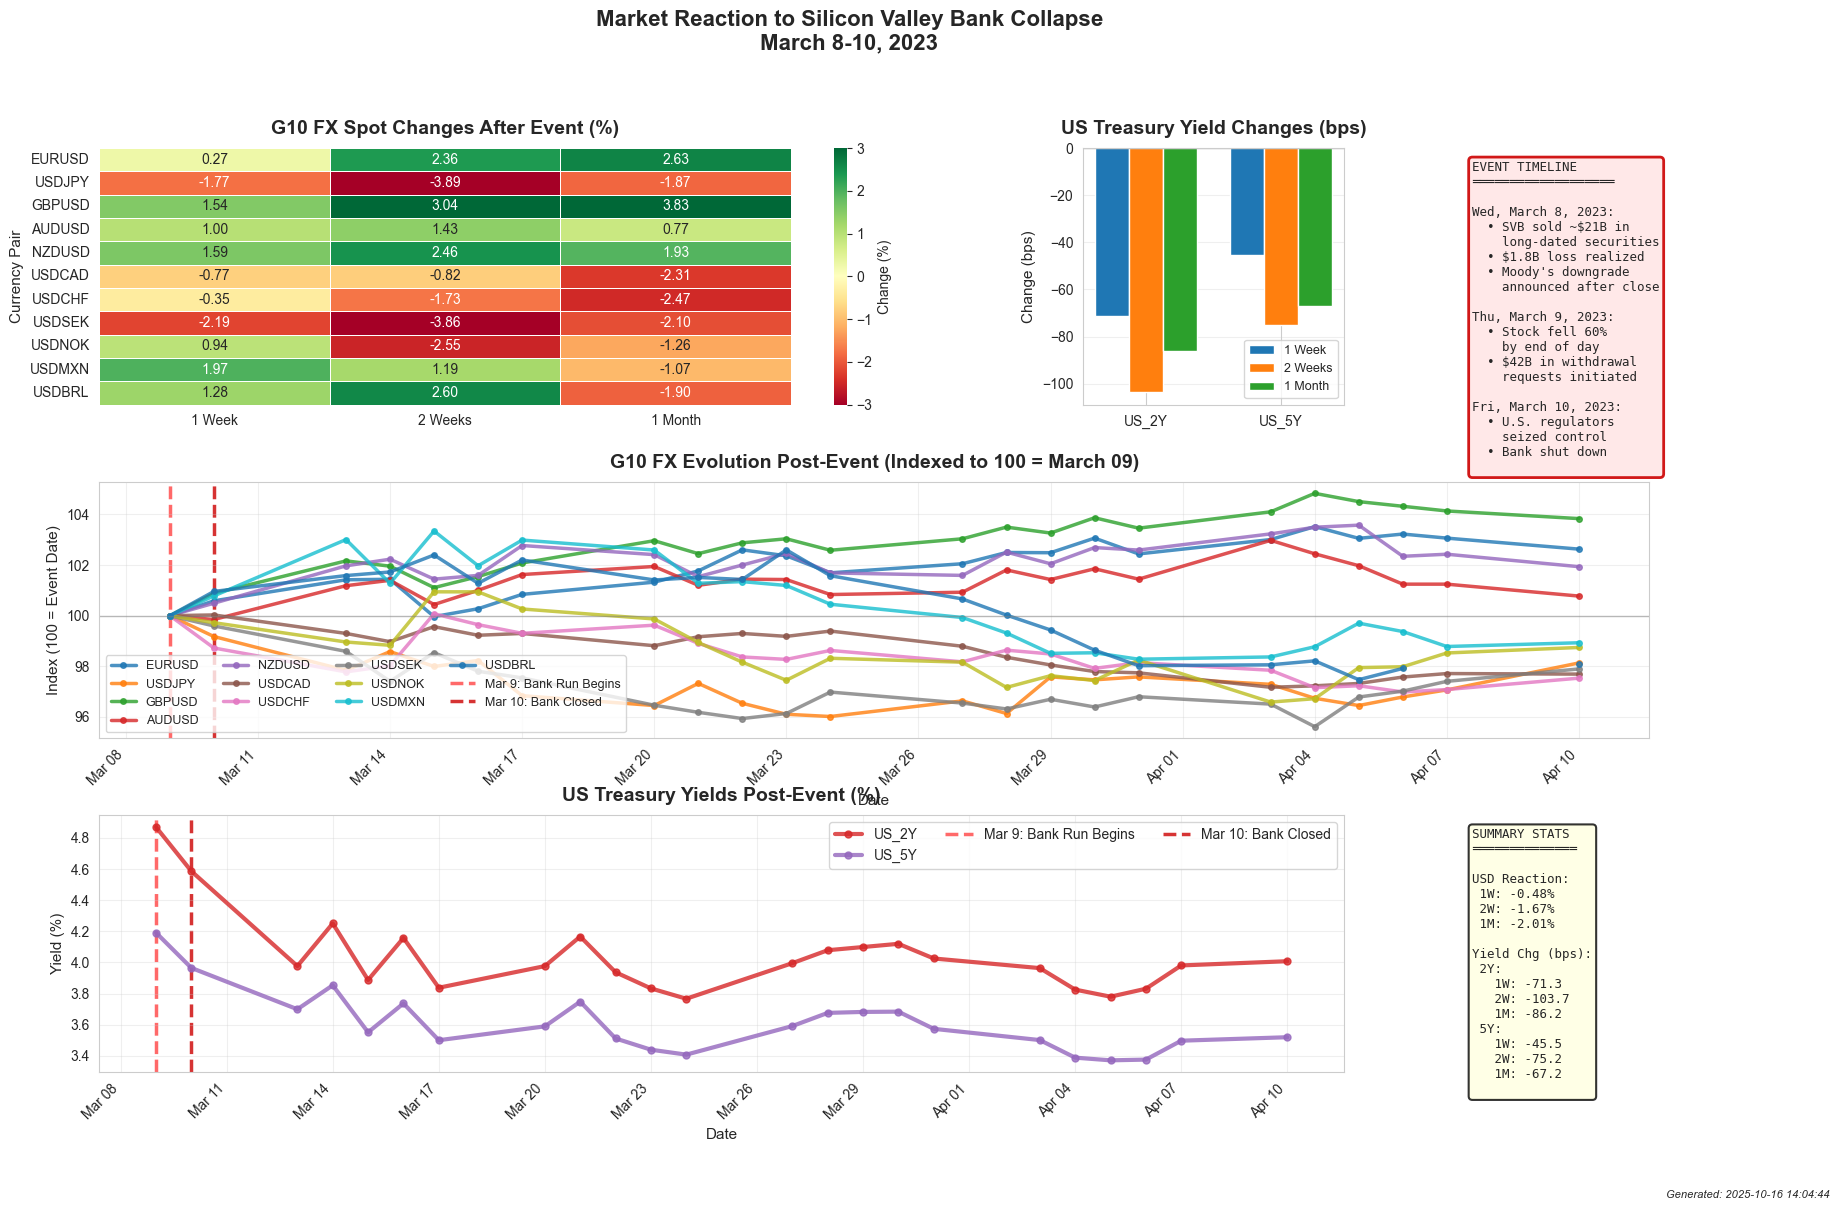

In [43]:
plot_svb_reaction(results)